# Importing Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt

#Data Preprocessing & Loading Dataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 112MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.33MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 57.7MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.9MB/s]


#Splitting Dataset

In [3]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])

#Creating DataLoaders

In [4]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

#Checking GPU Availability

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


#Building the Neural Network Model

In [6]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28*28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

#Defining Loss Function & Optimizer

In [7]:
model = MLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#Training the Model

In [8]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(10):

    #  TRAIN
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        predicted = torch.argmax(pred, dim=1)
        train_correct += (predicted == y).sum().item()
        train_total += y.size(0)

    train_loss = train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total


    # VALIDATION
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            pred = model(x)
            loss = criterion(pred, y)

            val_loss += loss.item()

            predicted = torch.argmax(pred, dim=1)
            val_correct += (predicted == y).sum().item()
            val_total += y.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
    )

Epoch 0 | Train Loss: 0.5462 | Train Acc: 81.18% | Val Loss: 0.3871 | Val Acc: 85.82%
Epoch 1 | Train Loss: 0.4140 | Train Acc: 85.13% | Val Loss: 0.3515 | Val Acc: 86.76%
Epoch 2 | Train Loss: 0.3797 | Train Acc: 86.26% | Val Loss: 0.3447 | Val Acc: 87.28%
Epoch 3 | Train Loss: 0.3565 | Train Acc: 87.03% | Val Loss: 0.3141 | Val Acc: 88.52%
Epoch 4 | Train Loss: 0.3394 | Train Acc: 87.56% | Val Loss: 0.3131 | Val Acc: 88.00%
Epoch 5 | Train Loss: 0.3274 | Train Acc: 88.03% | Val Loss: 0.3007 | Val Acc: 88.88%
Epoch 6 | Train Loss: 0.3160 | Train Acc: 88.24% | Val Loss: 0.2991 | Val Acc: 88.88%
Epoch 7 | Train Loss: 0.3043 | Train Acc: 88.67% | Val Loss: 0.2974 | Val Acc: 89.04%
Epoch 8 | Train Loss: 0.2945 | Train Acc: 89.07% | Val Loss: 0.2941 | Val Acc: 89.38%
Epoch 9 | Train Loss: 0.2834 | Train Acc: 89.52% | Val Loss: 0.2842 | Val Acc: 89.49%


#Evaluating the Model

In [9]:
model.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        pred = model(x)
        loss = criterion(pred, y)

        test_loss += loss.item()

        predicted = torch.argmax(pred, dim=1)

        correct += (predicted == y).sum().item()
        total += y.size(0)

test_loss = test_loss / len(test_loader)
test_acc = 100 * correct / total

print("FINAL TEST RESULTS")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

FINAL TEST RESULTS
Test Loss: 0.3148
Test Accuracy: 88.62%


#Visualizing Predictions

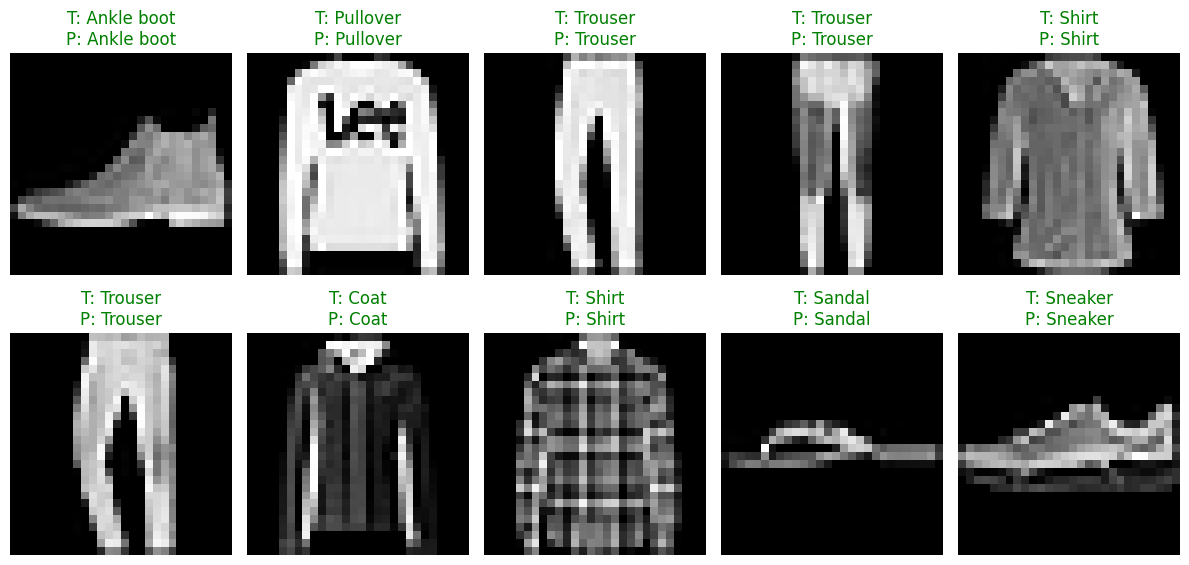

In [10]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")

    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]

    color = "green" if labels[i] == preds[i] else "red"

    plt.title(f"T: {true_label}\nP: {pred_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

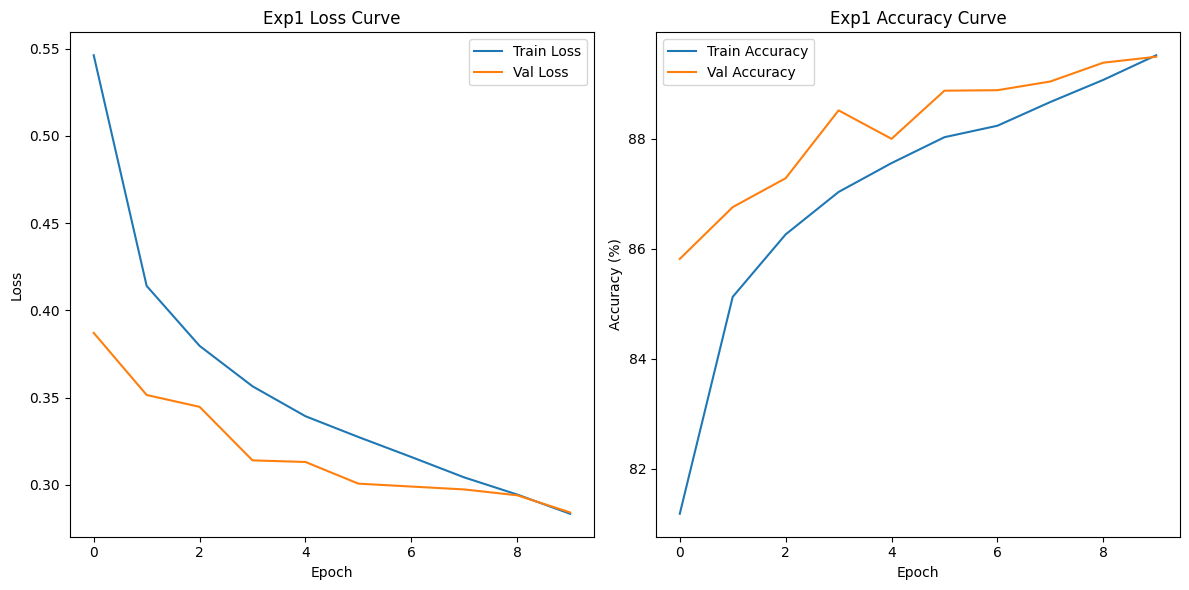

In [11]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Exp1 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.title("Exp1 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()

Experiment 2 (LR + Architecture Change) — Full Code
📌 1. Model (3 Hidden Layers)

In [12]:
class MLP2(nn.Module):
    def __init__(self):
        super(MLP2, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28*28, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

In [13]:
model2 = MLP2().to(device)

criterion = nn.CrossEntropyLoss()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.0001)

In [14]:
train_losses2 = []
val_losses2 = []
train_accs2 = []
val_accs2 = []

for epoch in range(10):

    #  TRAIN
    model2.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        pred = model2(x)
        loss = criterion(pred, y)

        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        train_loss += loss.item()

        predicted = torch.argmax(pred, dim=1)
        train_correct += (predicted == y).sum().item()
        train_total += y.size(0)

    train_loss = train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total

    # VALIDATION
    model2.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            pred = model2(x)
            loss = criterion(pred, y)

            val_loss += loss.item()

            predicted = torch.argmax(pred, dim=1)
            val_correct += (predicted == y).sum().item()
            val_total += y.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    train_losses2.append(train_loss)
    val_losses2.append(val_loss)
    train_accs2.append(train_acc)
    val_accs2.append(val_acc)

    print(
        f"[EXP2] Epoch {epoch} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
    )

[EXP2] Epoch 0 | Train Loss: 0.8167 | Train Acc: 76.49% | Val Loss: 0.4576 | Val Acc: 84.65%
[EXP2] Epoch 1 | Train Loss: 0.4723 | Train Acc: 84.33% | Val Loss: 0.3731 | Val Acc: 86.86%
[EXP2] Epoch 2 | Train Loss: 0.4088 | Train Acc: 86.08% | Val Loss: 0.3438 | Val Acc: 87.55%
[EXP2] Epoch 3 | Train Loss: 0.3771 | Train Acc: 86.80% | Val Loss: 0.3300 | Val Acc: 87.74%
[EXP2] Epoch 4 | Train Loss: 0.3540 | Train Acc: 87.41% | Val Loss: 0.3252 | Val Acc: 88.16%
[EXP2] Epoch 5 | Train Loss: 0.3394 | Train Acc: 87.92% | Val Loss: 0.3092 | Val Acc: 88.68%
[EXP2] Epoch 6 | Train Loss: 0.3257 | Train Acc: 88.41% | Val Loss: 0.3080 | Val Acc: 88.64%
[EXP2] Epoch 7 | Train Loss: 0.3143 | Train Acc: 88.63% | Val Loss: 0.2953 | Val Acc: 89.41%
[EXP2] Epoch 8 | Train Loss: 0.2972 | Train Acc: 89.33% | Val Loss: 0.3036 | Val Acc: 89.03%
[EXP2] Epoch 9 | Train Loss: 0.2939 | Train Acc: 89.36% | Val Loss: 0.2848 | Val Acc: 89.70%


In [15]:
model2.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        pred = model2(x)
        loss = criterion(pred, y)

        test_loss += loss.item()

        predicted = torch.argmax(pred, dim=1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

test_loss = test_loss / len(test_loader)
test_acc = 100 * correct / total

print("FINAL TEST RESULTS (EXP 2)")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

FINAL TEST RESULTS (EXP 2)
Test Loss: 0.3155
Test Accuracy: 88.61%


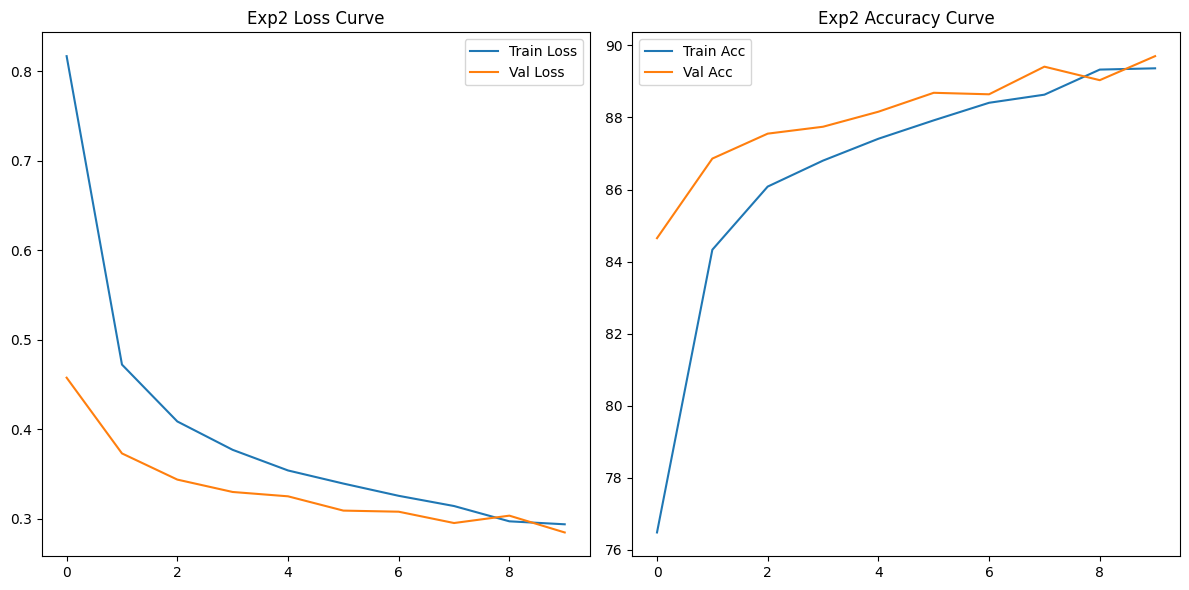

In [16]:
plt.figure(figsize=(12, 6))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses2, label="Train Loss")
plt.plot(val_losses2, label="Val Loss")
plt.title("Exp2 Loss Curve")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs2, label="Train Acc")
plt.plot(val_accs2, label="Val Acc")
plt.title("Exp2 Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["MLP (Exp1)", "MLP2 (Exp2)"],
    "Final Train Acc (%)": [train_accs[-1], train_accs2[-1]],
    "Final Val Acc (%)": [val_accs[-1], val_accs2[-1]],
    "Test Acc (%)": [test_acc, test_acc],
    "Final Train Loss": [train_losses[-1], train_losses2[-1]],
    "Final Val Loss": [val_losses[-1], val_losses2[-1]]
})

comparison.style.format({
    "Final Train Acc (%)": "{:.2f}",
    "Final Val Acc (%)": "{:.2f}",
    "Test Acc (%)": "{:.2f}",
    "Final Train Loss": "{:.4f}",
    "Final Val Loss": "{:.4f}"
})


,Model,Final Train Acc (%),Final Val Acc (%),Test Acc (%),Final Train Loss,Final Val Loss
0,MLP (Exp1),89.52,89.49,88.61,0.2834,0.2842
1,MLP2 (Exp2),89.36,89.70,88.61,0.2939,0.2848
